# Model Evaluation Figures (Section 8)

This notebook regenerates the evaluation figures for the report from the project's own data and final model settings. It re-runs the same **5-fold stratified cross-validation (shuffle=True, random_state=42)** on the **training data only**. The held-out test set is never loaded, so every figure is a cross-validation result and should be labelled that way in the report.

Final settings used (from each member's `candidate_metadata.json`):
- Logistic Regression: C = 0.05, class weight 1 : 2.5
- Gaussian Naive Bayes: RobustScaler, var_smoothing = 0.3, 15 columns
- Random Forest: 200 trees, max_depth = 20, min_samples_leaf = 2, max_features = 0.25, class weight 1 : 3.5
- Gradient Boosting: 120 trees, learning rate 0.05, depth 4, subsample 0.8, sample weight 1 : 2.5 (computed inside each training fold)

Run the cell with the **F1 check**. If all four models print `OK`, the figures match the reported results.

## 1. Load the data and set up cross-validation

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix,
                             f1_score, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.preprocessing.encoding_scaling import CATEGORICAL_COLUMNS, build_preprocessor  # noqa: E402

OUT = ROOT / "report_figures"
OUT.mkdir(exist_ok=True)
SEED = 42

X = pd.read_csv(ROOT / "data/processed/X_train_selected.csv")
y = pd.read_csv(ROOT / "data/y_train.csv").squeeze("columns").astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def split_cols(cols):
    cat = [c for c in CATEGORICAL_COLUMNS if c in cols]
    return [c for c in cols if c not in cat], cat

## 2. Final model configurations

In [2]:
# ---- final configurations (taken from each member's candidate_metadata.json) ----
num, cat = split_cols(list(X.columns))
nb_cols = [c for c in X.columns if c not in ["Informational", "Informational_Duration", "Administrative_Duration"]]
nb_num, nb_cat = split_cols(nb_cols)

MODELS = {
    "Logistic Regression": dict(
        cols=list(X.columns),
        pipe=Pipeline([("prep", build_preprocessor(num, cat)),
                       ("model", LogisticRegression(C=0.05, class_weight={0: 1.0, 1: 2.5},
                                                    max_iter=1000, random_state=SEED))]),
        weights=None),
    "Gaussian Naive Bayes": dict(
        cols=nb_cols,
        pipe=Pipeline([("prep", build_preprocessor(nb_num, nb_cat, scaler="robust")),
                       ("model", GaussianNB(var_smoothing=0.3))]),
        weights=None),
    "Random Forest": dict(
        cols=list(X.columns),
        pipe=Pipeline([("prep", build_preprocessor(num, cat)),
                       ("model", RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=2,
                                                        max_features=0.25, class_weight={0: 1.0, 1: 3.5},
                                                        n_jobs=-1, random_state=SEED))]),
        weights=None),
    "Gradient Boosting": dict(
        cols=list(X.columns),
        pipe=Pipeline([("prep", build_preprocessor(num, cat)),
                       ("model", GradientBoostingClassifier(n_estimators=120, learning_rate=0.05, max_depth=4,
                                                            subsample=0.8, random_state=SEED))]),
        weights={0: 1.0, 1: 2.5}),   # sample weights computed inside each training fold
}
COLORS = {"Logistic Regression": "#E8672F", "Gaussian Naive Bayes": "#E8A317",
          "Random Forest": "#1E9E78", "Gradient Boosting": "#2873D6"}

## 3. Run 5-fold CV and check the scores against the reported results
This stores the per-fold metrics and the out-of-fold probabilities used by the plots, and prints a comparison with the reported F1 scores.

In [3]:
# ---- run 5-fold CV, keep per-fold metrics and out-of-fold probabilities ----
fold_rows, oof = [], {}
for name, cfg in MODELS.items():
    prob = np.zeros(len(y))
    for k, (tr, va) in enumerate(cv.split(X, y), start=1):
        pipe = clone(cfg["pipe"])
        Xtr, Xva = X.iloc[tr][cfg["cols"]], X.iloc[va][cfg["cols"]]
        if cfg["weights"] is not None:
            w = compute_sample_weight(cfg["weights"], y.iloc[tr])
            pipe.fit(Xtr, y.iloc[tr], model__sample_weight=w)
        else:
            pipe.fit(Xtr, y.iloc[tr])
        p = pipe.predict_proba(Xva)[:, 1]
        pred = (p >= 0.5).astype(int)
        prob[va] = p
        yv = y.iloc[va]
        fold_rows.append(dict(model=name, fold=k, accuracy=accuracy_score(yv, pred),
                              precision=precision_score(yv, pred, zero_division=0),
                              recall=recall_score(yv, pred), f1=f1_score(yv, pred),
                              roc_auc=roc_auc_score(yv, p), pr_auc=average_precision_score(yv, p)))
    oof[name] = prob
    print("done", name)

folds = pd.DataFrame(fold_rows)
folds.to_csv(OUT / "cv_per_fold_metrics.csv", index=False)
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
summary = folds.groupby("model")[metrics].agg(["mean", "std"])
summary.columns = [f"{m}_{s}" for m, s in summary.columns]
summary = summary.loc[list(MODELS)]
summary.round(4).to_csv(OUT / "cv_model_comparison.csv")
print(summary[[f"{m}_mean" for m in metrics]].round(4).to_string())


# ---- reproducibility check against the project's reported CV F1 (docs/FINAL_MODEL_SELECTION.md) ----
REPORTED_F1 = {"Logistic Regression": 0.6729, "Gaussian Naive Bayes": 0.6453,
               "Random Forest": 0.6895, "Gradient Boosting": 0.6879}
print("\nF1 check (this run vs reported):")
for name, rep in REPORTED_F1.items():
    got = summary.loc[name, "f1_mean"]
    flag = "OK" if abs(got - rep) < 0.003 else "MISMATCH - check scikit-learn version / data"
    print(f"  {name:22s} {got:.4f} vs {rep:.4f}  {flag}")

done Logistic Regression
done Gaussian Naive Bayes
done Random Forest
done Gradient Boosting
                      accuracy_mean  precision_mean  recall_mean  f1_mean  roc_auc_mean  pr_auc_mean
model                                                                                               
Logistic Regression          0.8912          0.6355       0.7162   0.6729        0.9163       0.6791
Gaussian Naive Bayes         0.8802          0.6013       0.6979   0.6453        0.8892       0.6369
Random Forest                0.9025          0.7072       0.6435   0.6735        0.9295       0.7507
Gradient Boosting            0.8940          0.6371       0.7516   0.6892        0.9327       0.7482

F1 check (this run vs reported):
  Logistic Regression    0.6729 vs 0.6729  OK
  Gaussian Naive Bayes   0.6453 vs 0.6453  OK
  Random Forest          0.6735 vs 0.6895  MISMATCH - check scikit-learn version / data
  Gradient Boosting      0.6892 vs 0.6879  OK


## 4. Figures
Plot style settings.

In [4]:
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

### Figure: cross-validated performance of the four models
Mean 5-fold CV score for each metric. Suggested caption: *Figure 8.1: Cross-validated performance of the four models (5-fold stratified CV on the training data).*

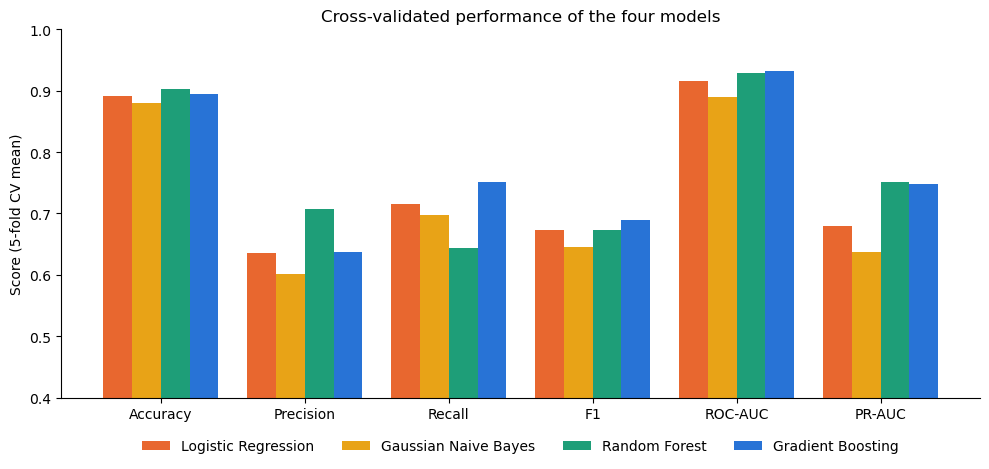

In [5]:
# 1. grouped bar chart of mean CV metrics
fig, ax = plt.subplots(figsize=(10, 4.8))
labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
w = 0.2
for i, name in enumerate(MODELS):
    vals = [summary.loc[name, f"{m}_mean"] for m in metrics]
    ax.bar(np.arange(6) + (i - 1.5) * w, vals, w, label=name, color=COLORS[name])
ax.set_xticks(range(6)); ax.set_xticklabels(labels)
ax.set_ylim(0.4, 1.0); ax.set_ylabel("Score (5-fold CV mean)")
ax.set_title("Cross-validated performance of the four models")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False)
fig.tight_layout(); fig.savefig(OUT / "fig_cv_metric_comparison.png", dpi=200); plt.show()

### Figure: F1 and ROC-AUC per fold
Suggested caption: *Figure 8.2: F1-score and ROC-AUC for each cross-validation fold.*

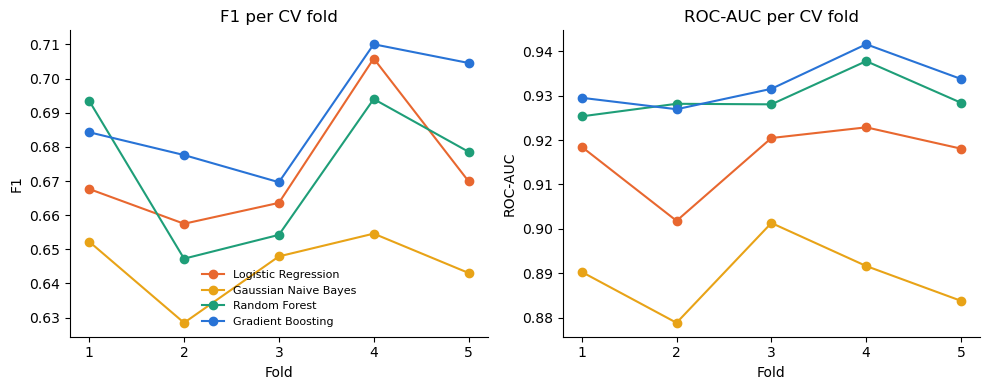

In [6]:
# 2. per-fold F1 and ROC-AUC
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, m, t in zip(axs, ["f1", "roc_auc"], ["F1 per CV fold", "ROC-AUC per CV fold"]):
    for name in MODELS:
        d = folds[folds.model == name]
        ax.plot(d.fold, d[m], marker="o", label=name, color=COLORS[name])
    ax.set_title(t); ax.set_xlabel("Fold"); ax.set_xticks(range(1, 6)); ax.set_ylabel(m.upper().replace("_", "-"))
axs[0].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "fig_cv_per_fold.png", dpi=200); plt.show()

### Figure: ROC curves
Pooled out-of-fold predictions. Suggested caption: *Figure 8.3: ROC curves for the four models based on out-of-fold predictions.*

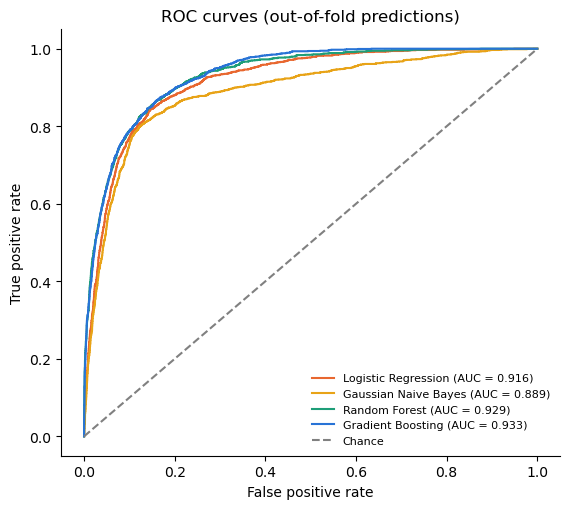

In [7]:
# 3. ROC curves (pooled out-of-fold predictions)
fig, ax = plt.subplots(figsize=(5.8, 5.2))
for name in MODELS:
    fpr, tpr, _ = roc_curve(y, oof[name])
    ax.plot(fpr, tpr, color=COLORS[name], label=f"{name} (AUC = {roc_auc_score(y, oof[name]):.3f})")
ax.plot([0, 1], [0, 1], "--", color="grey", label="Chance")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves (out-of-fold predictions)"); ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(OUT / "fig_roc_curves.png", dpi=200); plt.show()

### Figure: Precision-Recall curves
The dashed line is the no-skill level (the purchase rate). Suggested caption: *Figure 8.4: Precision-Recall curves based on out-of-fold predictions.*

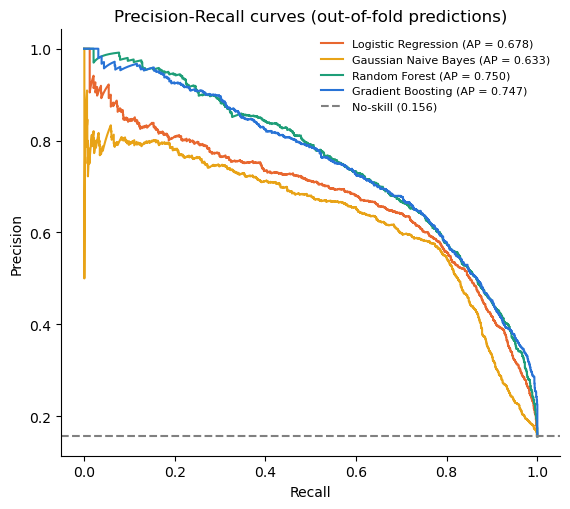

In [8]:
# 4. Precision-Recall curves (pooled out-of-fold predictions)
fig, ax = plt.subplots(figsize=(5.8, 5.2))
for name in MODELS:
    pr, rc, _ = precision_recall_curve(y, oof[name])
    ax.plot(rc, pr, color=COLORS[name], label=f"{name} (AP = {average_precision_score(y, oof[name]):.3f})")
ax.axhline(y.mean(), ls="--", color="grey", label=f"No-skill ({y.mean():.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves (out-of-fold predictions)"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "fig_pr_curves.png", dpi=200); plt.show()

### Figure: Random Forest confusion matrix
Out-of-fold predictions at the 0.5 threshold. Suggested caption: *Figure 8.5: Random Forest confusion matrix from 5-fold cross-validation.*

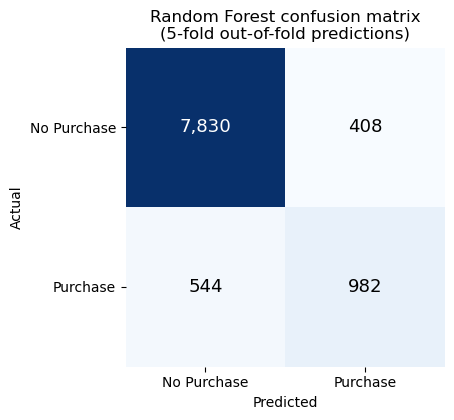

RF confusion matrix [[TN, FP], [FN, TP]]: [[7830, 408], [544, 982]]


In [9]:
# 5. Random Forest confusion matrix (out-of-fold, threshold 0.5)
cm = confusion_matrix(y, (oof["Random Forest"] >= 0.5).astype(int))
pd.DataFrame(cm, index=["Actual: No Purchase", "Actual: Purchase"],
             columns=["Predicted: No Purchase", "Predicted: Purchase"]).to_csv(OUT / "rf_confusion_matrix.csv")
fig, ax = plt.subplots(figsize=(5, 4.3))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_xticks([0, 1]); ax.set_xticklabels(["No Purchase", "Purchase"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["No Purchase", "Purchase"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Random Forest confusion matrix\n(5-fold out-of-fold predictions)")
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(); fig.savefig(OUT / "fig_rf_confusion_matrix.png", dpi=200); plt.show()
print("RF confusion matrix [[TN, FP], [FN, TP]]:", cm.tolist())

### Figure: Random Forest feature importance
Top 10 features from the saved `feature_importances.csv`. Suggested caption: *Figure 8.6: Top 10 Random Forest feature importances.*

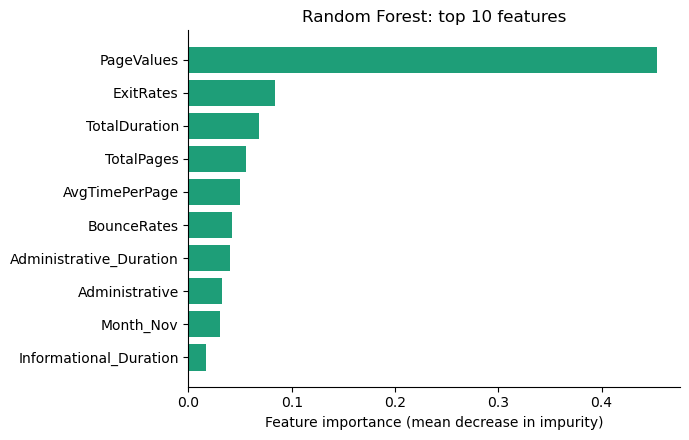

Saved figures to d:\FDM_Mini_Project\report_figures


In [10]:
# 6. Random Forest feature importance (top 10, from the project's saved results)
fi = pd.read_csv(ROOT / "results/member3_randomforest/feature_importances.csv")
fcol = [c for c in fi.columns if "import" in c.lower()][0]
ncol = [c for c in fi.columns if c != fcol][0]
top = fi.sort_values(fcol, ascending=False).head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top[ncol], top[fcol], color="#1E9E78")
ax.set_xlabel("Feature importance (mean decrease in impurity)")
ax.set_title("Random Forest: top 10 features")
fig.tight_layout(); fig.savefig(OUT / "fig_rf_feature_importance.png", dpi=200); plt.show()
print("Saved figures to", OUT)